# California Landscape Metrics Analysis

### A Natural Language Science Notebook

This notebook demonstrates **ARGUS** (Agentic Researcher Guide for Unified Science) extended via **MCP (Model Context Protocol)**. The `%%mcp` cell below registers an MCP server that exposes search and zonal-statistics tools over **California Landscape Metrics (CLM)** — a collection of nearly 200 high-resolution geospatial layers developed by an interagency science team for the California Wildfire and Forest Resilience Task Force to support land-manager planning of forest and shrubland resilience. Each analytical step is then expressed as a plain English `%%ask` prompt.

**What this notebook does (all queries hit CLM layers via MCP):**
1. Computes the average **carbon turnover time** in Los Angeles County
2. Finds the maximum **annual burn probability** in San Diego County
3. Visualizes the carbon turnover layer on a map
4. Shows the value distribution across San Diego
5. Ranks the top 5 California counties by mean carbon turnover time

**Requirements:** Set your `NRP_API_KEY` in `_User-Persistent-Storage_CephBlock_/.env` before running it on NDP JupyterHub.


In [ ]:
%reset

In [1]:
%%mcp
{ 
    "mcpServers": {
      "wenokn": {"url": "https://wenokn.fastmcp.app/mcp"}
    }
}

In [3]:
%%ask
What is the average carbon turnover time in Los Angeles?

Let me search for the relevant carbon turnover time dataset and compute the average for Los Angeles.

Now let me compute the zonal statistics for Los Angeles County.

Here are the results for **Aboveground Carbon Turnover Time in Los Angeles County** :

| Statistic | Value |
|---|---|
| **Mean** | **19.84 years** |
| **Min** | 0.0 years |
| **Max** | 200.0 years |
| **Std Dev** | 9.74 years |

**Interpretation** : The average aboveground carbon turnover time in Los Angeles County is approximately **19.8 years** . This represents the average lifetime of aboveground live and dead carbon. The relatively moderate mean suggests much of the county's carbon resides in somewhat labile pools (e.g., live/dead leaves in shrublands and grasslands). However, the high maximum of 200 years and standard deviation of ~9.7 years indicate localized pockets of highly stable carbon — likely in larger trees or coarse woody debris in the county's forested mountain areas (e.g., San Gabriel Mountains).

In [4]:
%%ask
Find the maximum annual burn probability in San Diego county

Let me search for a burn probability dataset first.

Now let me compute zonal statistics for San Diego County using the burn probability dataset.

Here are the results for **Annual Burn Probability in San Diego County** :

| Statistic | Value |
|---|---|
| **Maximum** | **0.0974 (≈ 9.7%)** |
| Mean | 0.0227 (≈ 2.3%) |
| Min | 0.0 (0%) |
| Std Dev | 0.0252 |

**Interpretation** : The maximum annual burn probability in San Diego County is approximately **9.7%** , meaning the most fire-prone pixel in the county has roughly a 1-in-10 chance of experiencing a wildfire in any given year. The average across the county is much lower at ~2.3%, with a standard deviation of ~2.5%, indicating significant spatial variation. The highest burn probabilities are likely concentrated in the county's backcountry areas with heavy fuel loads (e.g., Cleveland National Forest and surrounding shrublands), while coastal and urban areas sit near zero.

In [5]:
%%ask
Show me a map of the carbon turnover dataset

Let me search for the carbon turnover dataset to get the WMS layer details.

I have the WMS layer details. Let me create the WMS layer file to display the carbon turnover time dataset on a map.

Here's the map of the **Aboveground Carbon Turnover Time** dataset across California:

This layer shows the average lifetime of aboveground live and dead carbon in **years** . Areas with longer turnover times (darker colors) have more carbon in stable pools like large trees and coarse woody debris — typically found in the Sierra Nevada, Cascades, and North Coast forests. Areas with shorter turnover times (lighter colors) have more carbon in labile pools such as leaves and fine fuels, common in shrublands, grasslands, and deserts of Southern California and the Central Valley.

Let me create a visualization of this distribution.

Here's the distribution of aboveground carbon turnover time in San Diego County:


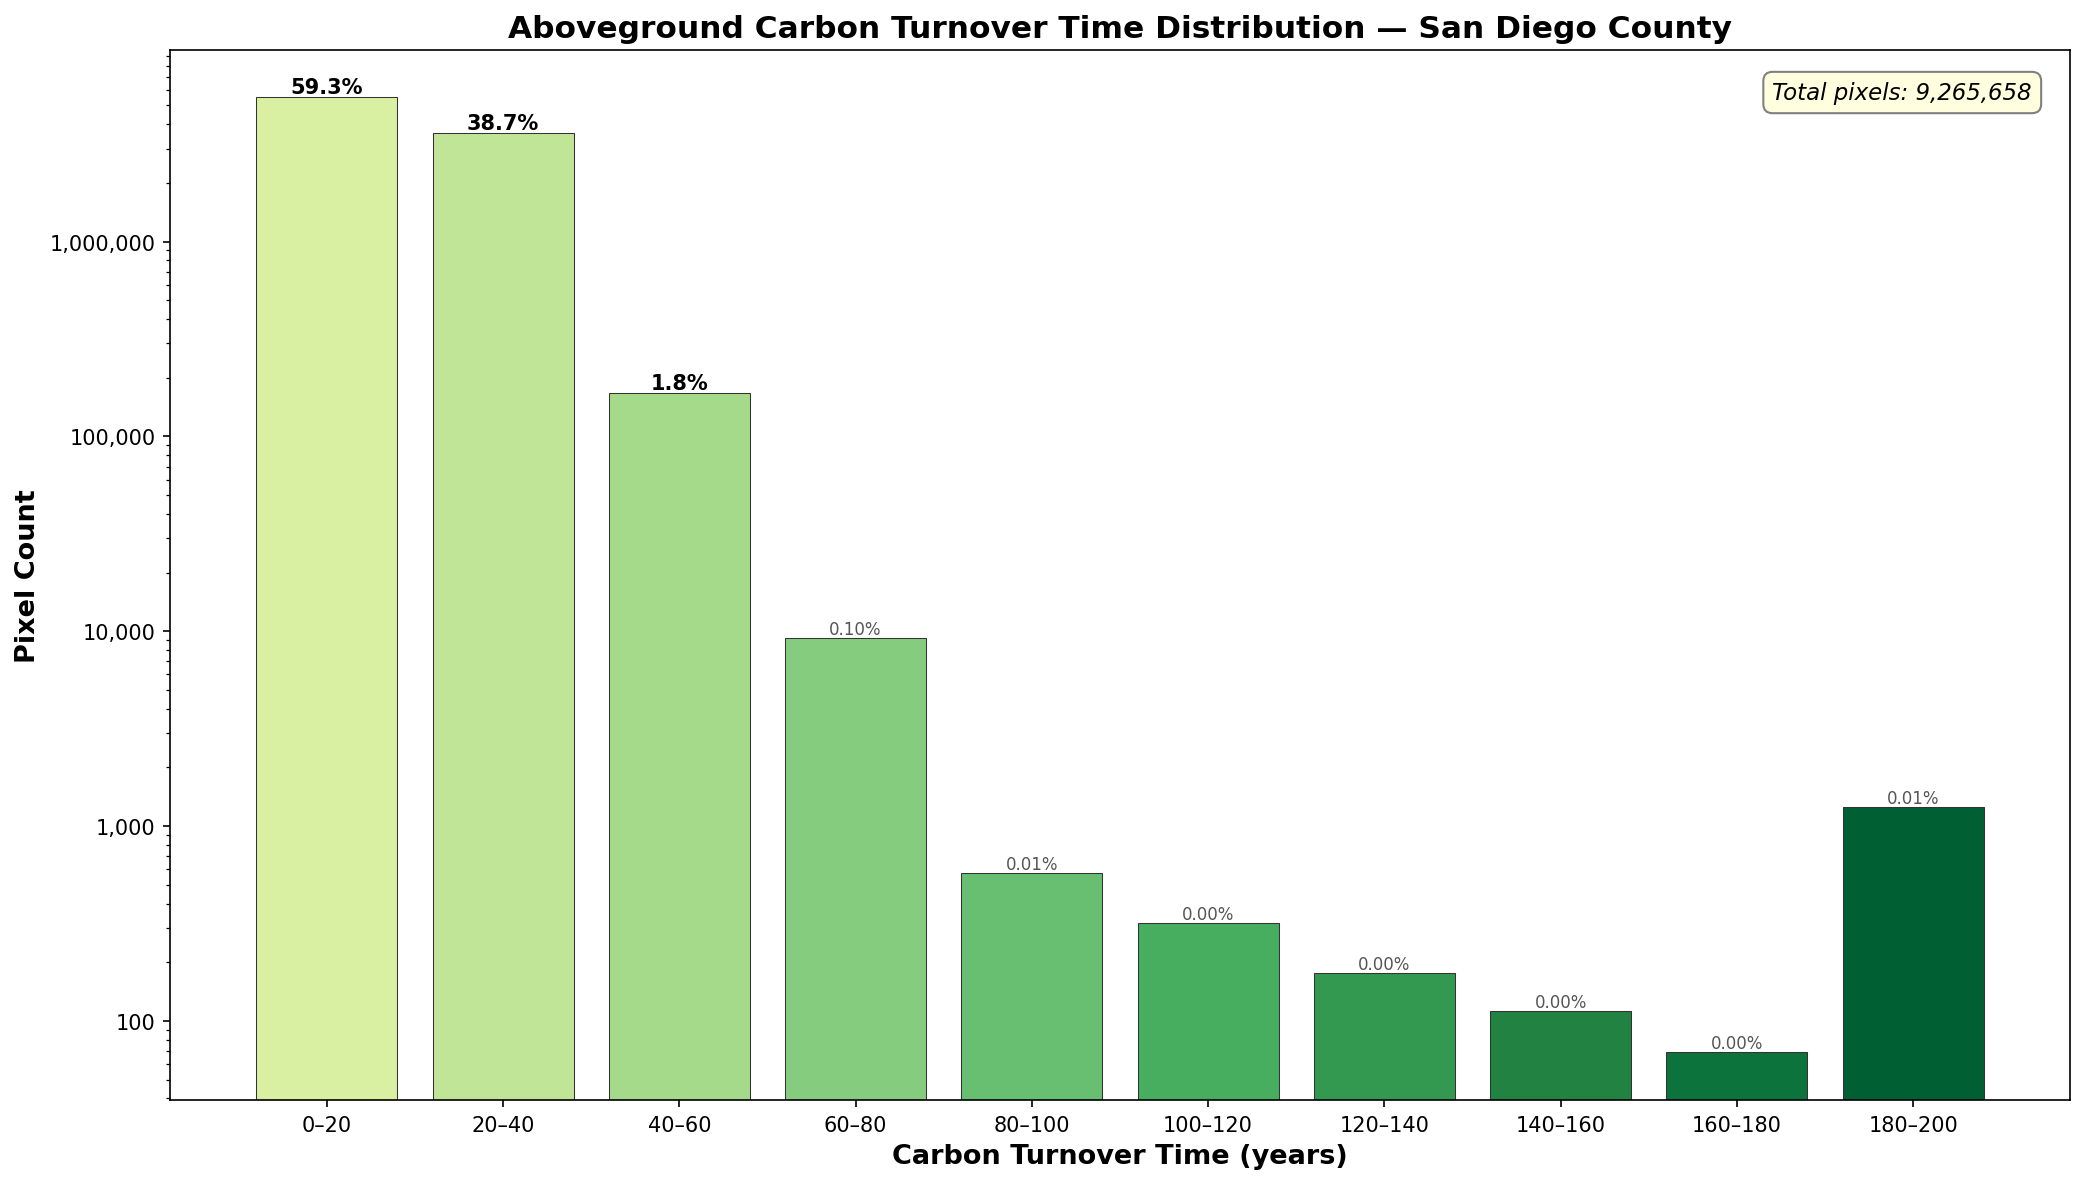

**Key findings:**

| Turnover Time Range | Pixel Count | % of County |
|---|---|---|
| **0–20 years** | 5,499,102 | **59.4%** |
| **20–40 years** | 3,588,521 | **38.7%** |
| 40–60 years | 166,347 | 1.8% |
| 60–80 years | 9,191 | 0.1% |
| 80–200 years | 2,097 | <0.05% |

The distribution is heavily right-skewed — **over 98% of San Diego County** has a carbon turnover time under 40 years. This is consistent with the county's dominant land cover of chaparral, shrublands, and grasslands, where carbon cycles relatively quickly. The small tail of pixels with turnover times above 60 years likely corresponds to forested areas in the higher elevations of the county (e.g., Palomar Mountain, Laguna Mountains).

In [6]:
%%ask
Show me the data distribution for San Diego

Let me compute mean carbon turnover time for all California counties at once.

Let me retry without the null filter value to process all counties.

Got results for all 58 counties. Let me create a bar chart of the top 5.

Here are the **Top 5 California Counties by Mean Aboveground Carbon Turnover Time** :

| Rank | County | Mean Turnover Time (years) |
|---|---|---|
| **1** | **Santa Cruz** | **44.8** |
| **2** | **Del Norte** | **43.4** |
| **3** | **Humboldt** | **42.5** |
| **4** | **San Mateo** | **38.1** |
| **5** | **Mendocino** | **37.4** |


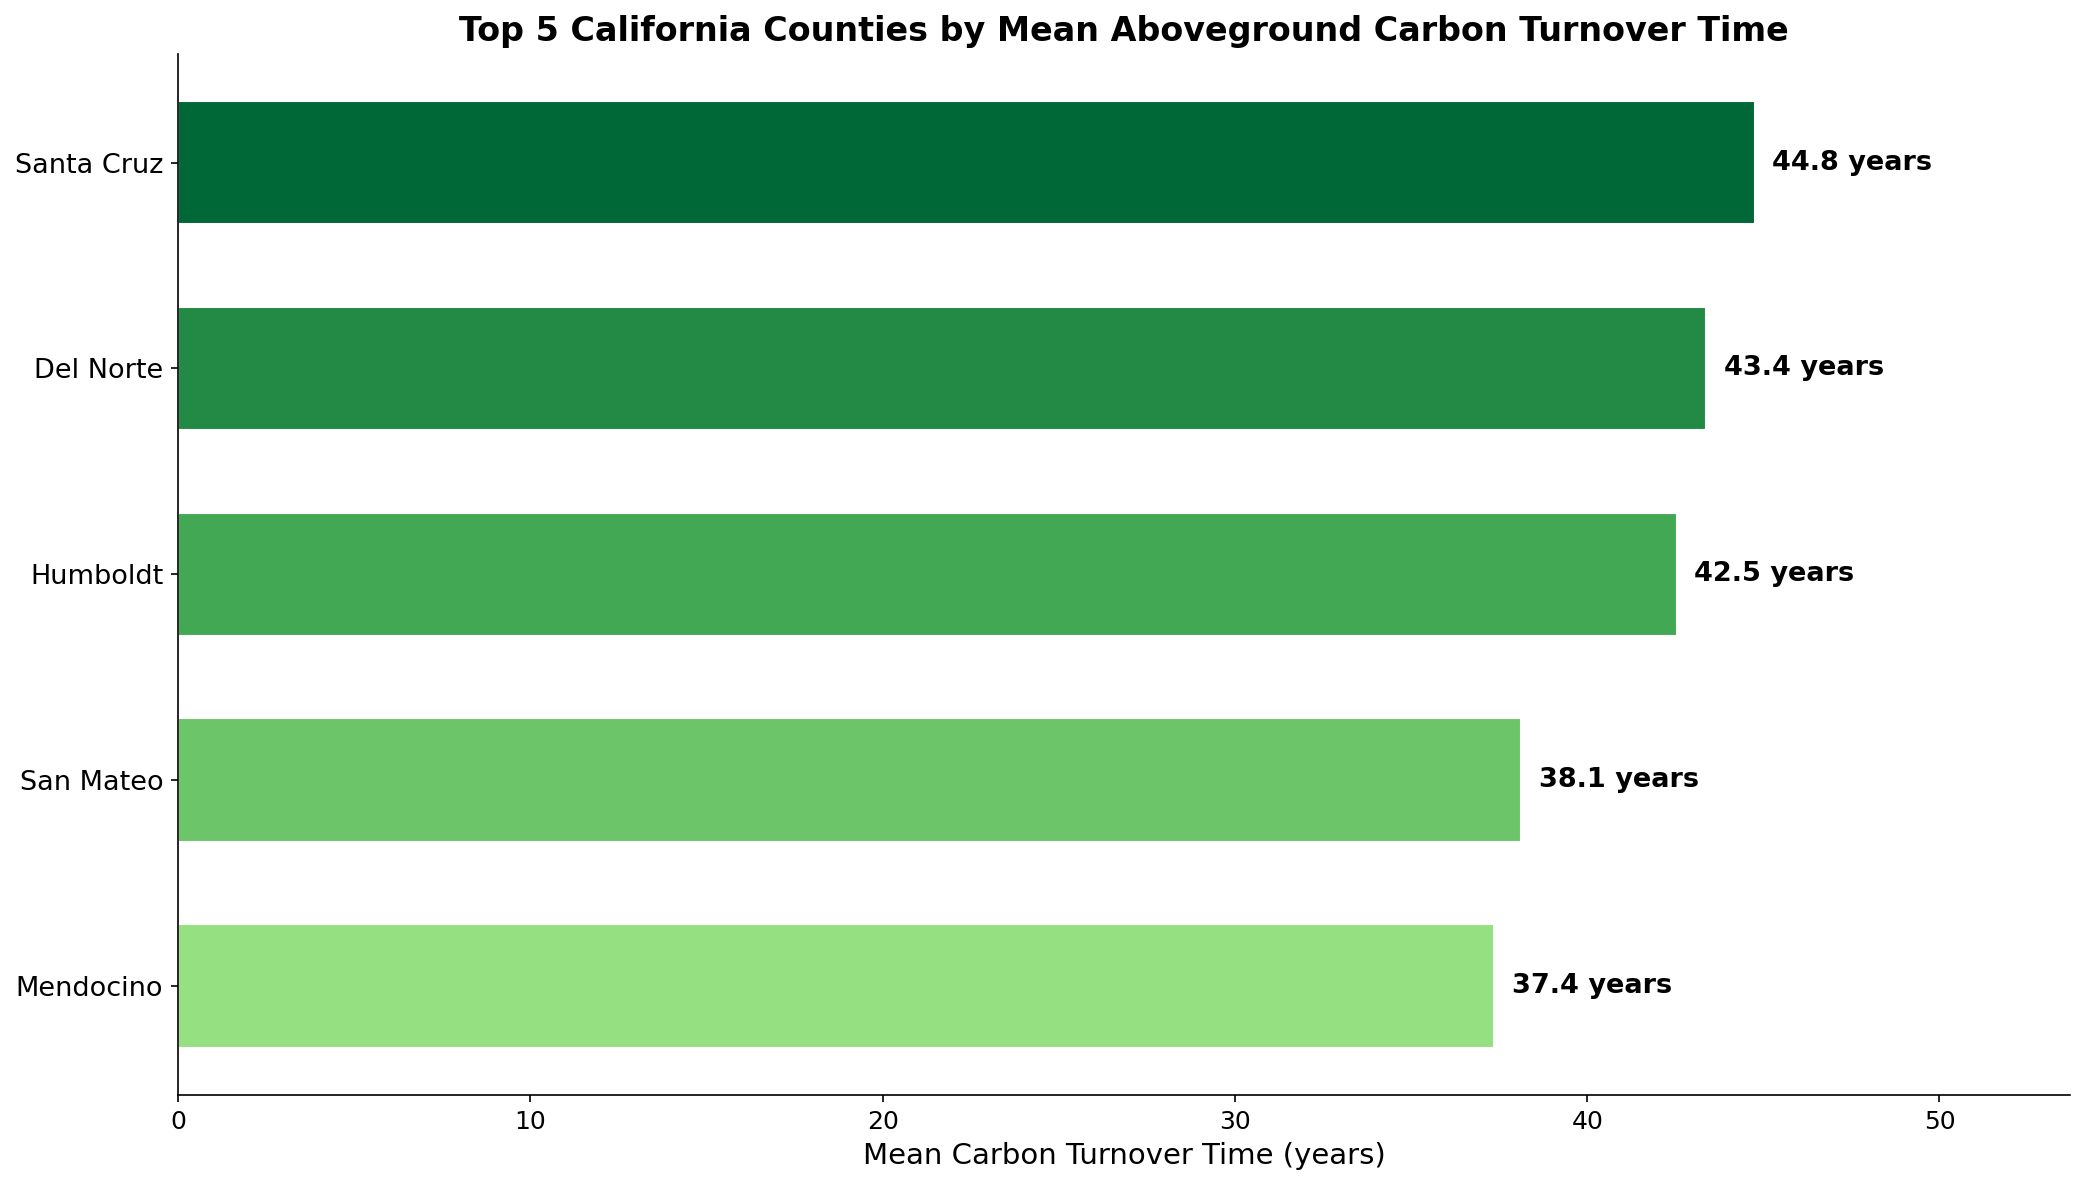

**Interpretation** : The top counties are overwhelmingly concentrated along California's **North Coast and Central Coast** regions, home to iconic redwood and mixed conifer forests. These areas store large proportions of their carbon in stable pools — mature tree trunks, coarse woody debris, and deep forest soils — which take decades to cycle. Santa Cruz leads at ~44.8 years, reflecting its dense coast redwood stands. Del Norte and Humboldt rank second and third, consistent with the vast old-growth and second-growth redwood/Douglas-fir forests of the northern coast. San Mateo's high ranking reflects its preserved forested watersheds (e.g., Santa Cruz Mountains), and Mendocino rounds out the top 5 with its extensive mixed hardwood and conifer forests.

For comparison, Southern California counties like Los Angeles (19.8 years) and San Diego (19.2 years) have roughly **half** the turnover time, reflecting their dominance by faster-cycling shrubland and grassland ecosystems.

In [2]:
%%ask
Rank the top 5 counties by mean carbon turnover time.